<a href="https://colab.research.google.com/github/anteodor/Numerical-Methods/blob/main/lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratory Work: Numerical Methods
**Student:** Anastasiia Teodorovska   
**Language:** Python (Google Colab)




## Task. Approximation of the Square Root Using the Babylonian Method

### 1. Problem Statement

The objective of this task is to implement and analyze an iterative numerical method for approximating the square root of a nonnegative real number.

Specifically, it is required to:

- implement the Babylonian method (also known as Heron’s method) for computing the value of $\sqrt{S}$;
- use a prescribed tolerance to control the stopping of the iterative process;
- determine whether the obtained approximation overestimates or underestimates the exact square root;
- present the iteration process in tabular form;
- visualize the convergence behavior of the method;
- analyze the accuracy and efficiency of the obtained approximation.

The computational problem can be formulated as the approximation of the positive root of the equation

$$
x^2 - S = 0,
$$

where

$$
S \geq 0.
$$

The approximation is performed iteratively until the required precision is achieved.

### 2. Mathematical Background

One of the oldest methods for approximating square roots is the Babylonian method, also known as Heron’s method. The idea of the method is based on the observation that if $x_n$ is an approximation to $\sqrt{S}$, then the value

$$
\frac{S}{x_n}
$$

provides a complementary estimate. If one of these values is greater than the exact square root, then the other is smaller. Therefore, taking their arithmetic mean produces a new approximation that is usually more accurate.

The iterative formula of the Babylonian method is

$$
x_{n+1} = \frac{1}{2}\left(x_n + \frac{S}{x_n}\right), \qquad n = 0,1,2,\dots
$$

where $x_0 > 0$ is an initial approximation.

This method can also be interpreted as an application of Newton’s method to the nonlinear equation

$$
f(x) = x^2 - S = 0.
$$

Indeed, Newton’s iteration for this equation is

$$
x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}
= x_n - \frac{x_n^2 - S}{2x_n}
= \frac{1}{2}\left(x_n + \frac{S}{x_n}\right),
$$

which coincides exactly with the Babylonian formula.

In the present task, the stopping criterion is based on the difference between two successive approximations. The iterative process is terminated when

$$
|x_n - x_{n-1}| \leq \text{TOL},
$$

where $\text{TOL}$ is a prescribed tolerance.

To determine whether the approximation overestimates or underestimates the exact value, the sign of the residual is analyzed:

$$
x_n^2 - S.
$$

If

$$
x_n^2 - S > 0,
$$

then the approximation is an overestimate. If

$$
x_n^2 - S < 0,
$$

then the approximation is an underestimate. If the residual is zero within machine precision, the approximation may be treated as exact.

### 3. Methodology

The implementation consists of the following steps:

1. Validation of the input parameters:
   - the value $S$ must be nonnegative;
   - the tolerance must be positive;
   - the maximum number of iterations must be a positive integer;
   - the initial approximation, if provided, must be positive.

2. Treatment of the special case

$$
S = 0,
$$

for which the exact square root is known immediately:

$$
\sqrt{0} = 0.
$$

3. Selection of the initial approximation $x_0$:
   - if the user specifies an initial guess, it is used directly;
   - otherwise, a default positive starting value is selected.

4. Application of the iterative formula

$$
x_{n+1} = \frac{1}{2}\left(x_n + \frac{S}{x_n}\right).
$$

5. Computation of the absolute change between successive approximations:

$$
e_n = |x_n - x_{n-1}|.
$$

6. Evaluation of the squared approximation

$$
x_n^2
$$

and the residual

$$
r_n = x_n^2 - S.
$$

7. Classification of each approximation as:
   - overestimate, if $r_n > 0$;
   - underestimate, if $r_n < 0$;
   - exact, if $|r_n|$ is below machine precision.

8. Storage of the full iteration history, including:
   - iteration number;
   - current approximation;
   - change from the previous step;
   - square of the approximation;
   - residual;
   - true error;
   - estimate type.

9. Construction of a pandas table for a structured representation of the iteration process.

10. Visualization of convergence using two plots:
   - the decay of the difference between successive approximations;
   - the decay of the true error

$$
|x_n - \sqrt{S}|.
$$

11. Generation of an automatic analysis section summarizing the computational results, convergence, and accuracy of the method.

### 4. Program Implementation

The program was implemented in Python in the Google Colab environment.

To improve the structure, readability, and maintainability of the solution, the implementation was organized into several logical components.

Two data classes were introduced:

- `IterationRecord` — stores all relevant information for a single iteration;
- `BabylonianResult` — stores the final result of the method together with the complete iteration history.

A separate function was implemented to classify the current approximation as an overestimate, underestimate, or exact value on the basis of the residual

$$
x_n^2 - S.
$$

The main computational procedure performs the Babylonian iteration, checks the stopping criterion, and records the full iteration process.

Additionally, helper functions were developed for:

- printing the result in a console-friendly format;
- converting the iteration history into a pandas DataFrame;
- displaying the table in a well-formatted form suitable for Google Colab;
- plotting convergence graphs;
- generating a textual analysis of the computational experiment.

Such decomposition of the program into small specialized functions makes the solution more transparent, reusable, and academically well-structured.

In [11]:
from dataclasses import dataclass
from typing import List, Optional
import pandas as pd
import matplotlib.pyplot as plt


@dataclass
class IterationRecord:
    iteration: int
    x_n: float
    absolute_error_estimate: Optional[float]
    squared_value: float
    residual: float
    estimate_type: str


@dataclass
class BabylonianResult:
    S: float
    approximation: float
    tolerance: float
    max_iterations: int
    iterations_used: int
    converged: bool
    estimate_type: str
    history: List[IterationRecord]


def classify_estimate(S: float, approximation: float, eps: float = 1e-15) -> str:

    difference = approximation * approximation - S

    if abs(difference) <= eps:
        return "exact"
    if difference > 0:
        return "overestimate"
    return "underestimate"


def babylonian_sqrt(
    S: float,
    tolerance: float = 1e-10,
    max_iterations: int = 100,
    initial_guess: Optional[float] = None,
    store_history: bool = True
) -> BabylonianResult:

    if S < 0:
        raise ValueError("S must be non-negative.")
    if tolerance <= 0:
        raise ValueError("tolerance must be positive.")
    if max_iterations <= 0:
        raise ValueError("max_iterations must be a positive integer.")

    if S == 0:
        record = IterationRecord(
            iteration=0,
            x_n=0.0,
            absolute_error_estimate=0.0,
            squared_value=0.0,
            residual=0.0,
            estimate_type="exact"
        )
        return BabylonianResult(
            S=S,
            approximation=0.0,
            tolerance=tolerance,
            max_iterations=max_iterations,
            iterations_used=0,
            converged=True,
            estimate_type="exact",
            history=[record] if store_history else []
        )

    if initial_guess is None:
        x_prev = S if S >= 1 else 1.0
    else:
        if initial_guess <= 0:
            raise ValueError("initial_guess must be positive.")
        x_prev = float(initial_guess)

    history: List[IterationRecord] = []

    initial_type = classify_estimate(S, x_prev)
    if store_history:
        history.append(
            IterationRecord(
                iteration=0,
                x_n=x_prev,
                absolute_error_estimate=None,
                squared_value=x_prev * x_prev,
                residual=(x_prev * x_prev - S),
                estimate_type=initial_type
            )
        )

    converged = False
    x_current = x_prev

    for iteration in range(1, max_iterations + 1):
        x_current = 0.5 * (x_prev + S / x_prev)
        error_estimate = abs(x_current - x_prev)
        current_type = classify_estimate(S, x_current)

        if store_history:
            history.append(
                IterationRecord(
                    iteration=iteration,
                    x_n=x_current,
                    absolute_error_estimate=error_estimate,
                    squared_value=x_current * x_current,
                    residual=(x_current * x_current - S),
                    estimate_type=current_type
                )
            )

        if error_estimate <= tolerance:
            converged = True
            break

        x_prev = x_current

    return BabylonianResult(
        S=S,
        approximation=x_current,
        tolerance=tolerance,
        max_iterations=max_iterations,
        iterations_used=iteration,
        converged=converged,
        estimate_type=classify_estimate(S, x_current),
        history=history
    )


def print_result(result: BabylonianResult, show_history: bool = True) -> None:

    print("\n\n")
    print("BABYLONIAN METHOD RESULT")
    print("-" * 60)
    print(f"S                  : {result.S}")
    print(f"Approximation      : {result.approximation:.15f}")
    print(f"Tolerance          : {result.tolerance}")
    print(f"Max iterations     : {result.max_iterations}")
    print(f"Iterations used    : {result.iterations_used}")
    print(f"Converged          : {result.converged}")
    print(f"Final estimate type: {result.estimate_type}")
    print("-" * 60)

    if show_history and result.history:
        print("\nIteration history:")
        print(
            f"{'n':>3} | {'x_n':>20} | {'|x_n-x_(n-1)|':>18} | "
            f"{'x_n^2':>20} | {'x_n^2 - S':>20} | {'type':>14}"
        )
        print("-" * 110)

        for row in result.history:
            error_text = (
                f"{row.absolute_error_estimate:.12e}"
                if row.absolute_error_estimate is not None
                else "N/A"
            )
            print(
                f"{row.iteration:>3} | "
                f"{row.x_n:>20.15f} | "
                f"{error_text:>18} | "
                f"{row.squared_value:>20.15f} | "
                f"{row.residual:>20.12e} | "
                f"{row.estimate_type:>14}"
            )


def create_table(result: BabylonianResult) -> pd.DataFrame:

    table_data = []

    true_value = result.S ** 0.5

    for record in result.history:
        table_data.append({
            "Iteration": record.iteration,
            "Approximation (x_n)": record.x_n,
            "Change from Previous Step": record.absolute_error_estimate,
            "Square of Approximation": record.squared_value,
            "Difference from S": record.residual,
            "True Error": abs(record.x_n - true_value),
            "Estimate Type": record.estimate_type
        })

    return pd.DataFrame(table_data)


def display_table(result: BabylonianResult):

    df = create_table(result)

    styled = (
        df.style
        .format({
            "Approximation (x_n)": "{:.15f}",
            "Change from Previous Step": lambda x: f"{x:.12e}" if pd.notnull(x) else "N/A",
            "Square of Approximation": "{:.15f}",
            "Difference from S": "{:.12e}",
            "True Error": "{:.12e}"
        })
        .set_caption("Babylonian Method Iteration Table")

        .set_table_styles([
            {"selector": "caption", "props": [("caption-side", "top"), ("padding-top", "20px")]},
            {"selector": "th", "props": [("text-align", "left")]},
            {"selector": "td", "props": [("text-align", "left")]}
        ])
    )

    return styled


def plot_convergence(result: BabylonianResult) -> None:

    df = create_table(result).copy()

    # remove the first row for step-change plot because it contains N/A
    df_change = df[df["Change from Previous Step"].notna()].copy()

    plt.figure(figsize=(10, 5))
    plt.plot(
        df_change["Iteration"],
        df_change["Change from Previous Step"],
        marker="o"
    )
    plt.yscale("log")
    plt.xlabel("Iteration")
    plt.ylabel("Absolute change between successive approximations")
    plt.title("Convergence of the Babylonian Method")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(
        df["Iteration"],
        df["True Error"],
        marker="o"
    )
    plt.yscale("log")
    plt.xlabel("Iteration")
    plt.ylabel("True error")
    plt.title("Decay of the True Error")
    plt.grid(True)
    plt.show()


def generate_analysis(result: BabylonianResult) -> str:

    df = create_table(result)
    true_value = result.S ** 0.5

    final_approximation = result.approximation
    final_true_error = abs(final_approximation - true_value)
    initial_true_error = df.loc[0, "True Error"]
    final_estimate_type = result.estimate_type

    if len(df) > 1:
        last_change = df["Change from Previous Step"].dropna().iloc[-1]
    else:
        last_change = 0.0

    analysis_text = f"""
ANALYSIS SECTION

The Babylonian method was applied to approximate the square root of S = {result.S}.
The method started from an initial approximation and iteratively refined the result
using the recurrence relation.

The iterative process {'successfully converged' if result.converged else 'did not converge'}
within the prescribed tolerance of {result.tolerance}. The algorithm required
{result.iterations_used} iteration(s) to produce the final approximation.

The final approximation is:
{final_approximation:.15f}

For comparison, the reference value of sqrt(S) is:
{true_value:.15f}

The final true error is:
{final_true_error:.12e}

The final approximation is classified as:
{final_estimate_type}

The initial true error was:
{initial_true_error:.12e}

The final change between successive approximations was:
{last_change:.12e}

The iteration table shows that the approximation improved rapidly from one step
to the next. Both the difference between successive approximations and the true
error decreased significantly, confirming fast convergence of the method.

The convergence plots further demonstrate that the method is highly efficient.
The error decreases very quickly, which is consistent with the known quadratic
convergence behavior of the Babylonian method when the initial guess is positive
and sufficiently reasonable.

Therefore, the computational experiment confirms that the Babylonian method is
an accurate, stable, and efficient iterative technique for approximating square roots.
""".strip()

    return analysis_text


In [12]:
# Example usage
S = 10
tolerance = 1e-8
max_iterations = 100
initial_guess = 3.0

result = babylonian_sqrt(
    S=S,
    tolerance=tolerance,
    max_iterations=max_iterations,
    initial_guess=initial_guess,
    store_history=True
)

In [13]:
print_result(result, show_history=True)





BABYLONIAN METHOD RESULT
------------------------------------------------------------
S                  : 10
Approximation      : 3.162277660168379
Tolerance          : 1e-08
Max iterations     : 100
Iterations used    : 4
Converged          : True
Final estimate type: underestimate
------------------------------------------------------------

Iteration history:
  n |                  x_n |      |x_n-x_(n-1)| |                x_n^2 |            x_n^2 - S |           type
--------------------------------------------------------------------------------------------------------------
  0 |    3.000000000000000 |                N/A |    9.000000000000000 |  -1.000000000000e+00 |  underestimate
  1 |    3.166666666666667 | 1.666666666667e-01 |   10.027777777777780 |   2.777777777778e-02 |   overestimate
  2 |    3.162280701754386 | 4.385964912281e-03 |   10.000019236688212 |   1.923668821213e-05 |   overestimate
  3 |    3.162277660169842 | 3.041584544228e-06 |   10.000000000009249 |   9

In [14]:
display_table(result)

,Iteration,Approximation (x_n),Change from Previous Step,Square of Approximation,Difference from S,True Error,Estimate Type
0,0,3.000000000000000,N/A,9.000000000000000,-1.000000000000e+00,1.622776601684e-01,underestimate
1,1,3.166666666666667,1.666666666667e-01,10.027777777777780,2.777777777778e-02,4.389006498287e-03,overestimate
2,2,3.162280701754386,4.385964912281e-03,10.000019236688212,1.923668821213e-05,3.041586006614e-06,overestimate
3,3,3.162277660169842,3.041584544228e-06,10.000000000009249,9.249490062757e-12,1.462385768036e-12,overestimate
4,4,3.162277660168379,1.462829857246e-12,9.999999999999998,-1.776356839400e-15,4.440892098501e-16,underestimate


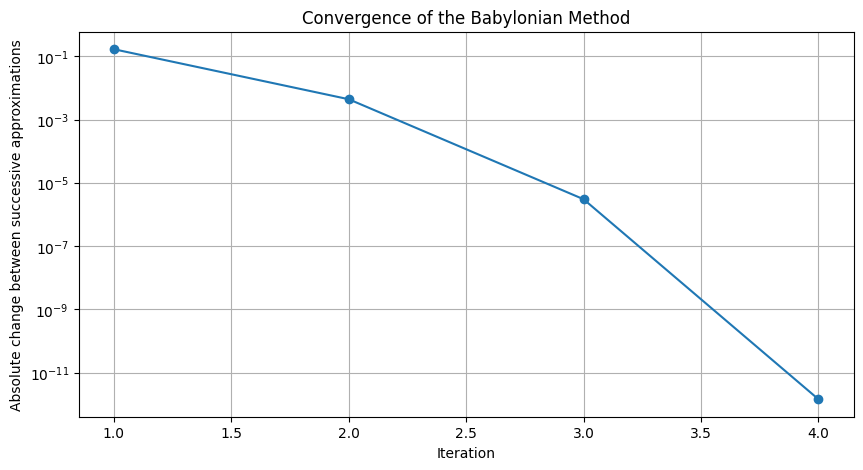

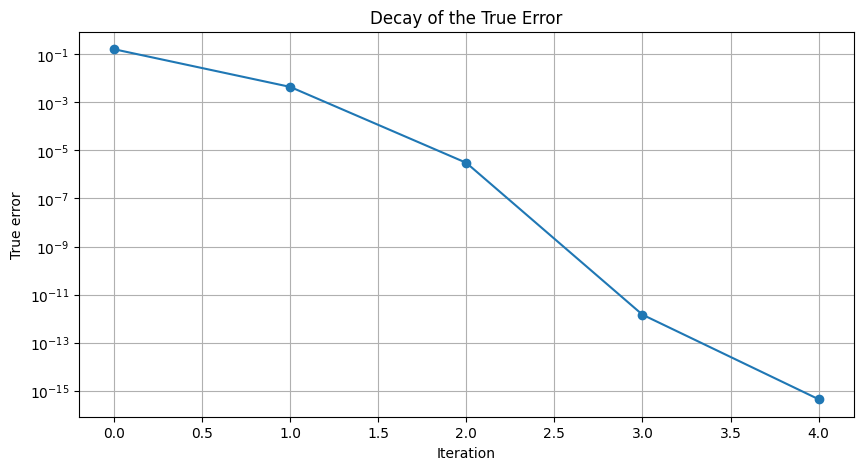

In [15]:
plot_convergence(result)

In [16]:
print(generate_analysis(result))

ANALYSIS SECTION

The Babylonian method was applied to approximate the square root of S = 10.
The method started from an initial approximation and iteratively refined the result
using the recurrence relation.

The iterative process successfully converged
within the prescribed tolerance of 1e-08. The algorithm required
4 iteration(s) to produce the final approximation.

The final approximation is:
3.162277660168379

For comparison, the reference value of sqrt(S) is:
3.162277660168380

The final true error is:
4.440892098501e-16

The final approximation is classified as:
underestimate

The initial true error was:
1.622776601684e-01

The final change between successive approximations was:
1.462829857246e-12

The iteration table shows that the approximation improved rapidly from one step
to the next. Both the difference between successive approximations and the true
error decreased significantly, confirming fast convergence of the method.

The convergence plots further demonstrate that the

### 5. Results and Analysis

The computational experiment confirms that the Babylonian method provides a fast and accurate approximation of the square root.

The iteration table shows how the approximation evolves from the initial guess toward the exact value. At each step, the following quantities are monitored:

- the current approximation;
- the change from the previous iteration;
- the square of the approximation;
- the residual relative to $S$;
- the true error;
- the estimate classification.

The obtained results demonstrate that the method converges very rapidly. The difference between two successive approximations decreases significantly after each iteration, indicating stabilization of the iterative process.

The true error

$$
|x_n - \sqrt{S}|
$$

also decreases quickly, which confirms the high efficiency of the method.

The residual

$$
x_n^2 - S
$$

provides additional information about the position of the approximation relative to the exact root. Positive residual values indicate overestimation, while negative values indicate underestimation. This makes it possible not only to approximate the square root, but also to interpret the direction of the approximation at every iteration.

The convergence plots further support the numerical results. When the values are displayed on a logarithmic scale, both the successive-step difference and the true error exhibit a rapid decrease. This behavior is consistent with the well-known quadratic convergence of the Babylonian method, provided that the initial approximation is positive and reasonably chosen.

Thus, the conducted analysis shows that the method is numerically stable, computationally efficient, and highly suitable for the approximation of square roots.

### 6. Interpretation of the Iteration Table

The iteration table provides a detailed view of the numerical behavior of the method.

Each row corresponds to one iteration and contains:

- **Iteration** — the current iteration number;
- **Approximation** — the value of the current approximation $x_n$;
- **Change from Previous Step** — the absolute difference

$$
|x_n - x_{n-1}|,
$$

  which is used as the stopping criterion;
- **Square of Approximation** — the value $x_n^2$, used to compare the approximation with the original number $S$;
- **Difference from S** — the residual

$$
x_n^2 - S;
$$

- **True Error** — the absolute deviation from the exact square root

$$
|x_n - \sqrt{S}|;
$$

- **Estimate Type** — indicates whether the current approximation is an overestimate, underestimate, or exact value.

This tabular representation is particularly useful for understanding not only the final numerical result, but also the dynamics of convergence and the quality of intermediate approximations.

### 7. Interpretation of the Convergence Graphs

Two graphical representations were used to analyze the convergence of the Babylonian method.

The first graph shows the decay of the absolute change between successive approximations:

$$
|x_n - x_{n-1}|.
$$

This graph illustrates how quickly the iterative process stabilizes. A rapid decrease of this quantity indicates that the method approaches a fixed value in a small number of steps.

The second graph shows the decay of the true error:

$$
|x_n - \sqrt{S}|.
$$

This graph provides direct information about the actual approximation accuracy. Its rapid decline demonstrates that the computed value approaches the exact square root very efficiently.

Both plots were represented on a logarithmic scale, which makes the convergence behavior more transparent and easier to interpret. The nearly linear downward trend on the logarithmic axis is characteristic of very fast convergence.

Together, the graphs confirm that the Babylonian method is not only theoretically sound, but also highly effective in practical computation.

### 8. Conclusion

In this task, the Babylonian method for approximating the square root of a nonnegative real number was implemented and analyzed.

The study showed that the method is based on a simple yet powerful iterative formula,

$$
x_{n+1} = \frac{1}{2}\left(x_n + \frac{S}{x_n}\right),
$$

which can also be derived from Newton’s method applied to the equation

$$
x^2 - S = 0.
$$

The developed program successfully computes the approximation of $\sqrt{S}$ with a prescribed tolerance, determines whether the result overestimates or underestimates the exact value, stores the full iteration history, and presents the results in both tabular and graphical form.

The numerical experiment demonstrated rapid convergence of the method. Both the difference between successive approximations and the true error decreased very quickly, confirming the high efficiency and accuracy of the algorithm.

The residual analysis made it possible to classify the approximations at each step, which provided additional insight into the behavior of the iterative process.

Overall, this task illustrates important concepts of numerical methods, including iterative approximation, stopping criteria, residual analysis, convergence behavior, and the practical implementation of mathematically grounded algorithms in Python.